<a href="https://colab.research.google.com/github/Jenyy0416/cs1090b_project/blob/main/ms3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 1090B Project Milestone 3

*Group project number:* 41

*Group members:* You Wu, Jenny Yang, Xuyang Sun, Yifan Xu, Jiaxi Liu

In [1]:
# load the dataset from Hugging Face
from datasets import load_dataset

# import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import random
import torch
import io
from PIL import Image
from collections import Counter
from pathlib import Path
import re
from wordcloud import WordCloud

# set random seeds for reproducibility
random.seed(109)
np.random.seed(109)
torch.manual_seed(109)

 # 1. Problem Statement Refinement and introduction:


## Redefinition & Rescoping of the Problem Statement

The original project proposal framed this task as a chest X-ray image-to-text problem, with the goal of generating short medical findings from paired radiology images and reports in the dataset. The proposed workflow used a deep learning pipeline with an image encoder to extract visual features from chest X-rays, a sequence decoder to generate report text, next-token prediction as the training objective, and BLEU and ROUGE as evaluation metrics.

After preprocessing and exploratory data analysis, we refined this initial idea to better match the actual structure and limitations of the cleaned dataset. In particular, the text fields are not equally suitable for generation: the `findings` section is longer, noisier, and more incomplete, whereas the `impression` section is shorter, more standardized, and more consistently available. In addition, the cleaned dataset contains only a few thousand valid studies, which makes full report generation or highly complex modeling less realistic for the current project scope. For this reason, we narrow the task from generating full findings to generating a short impression summary, which is both more feasible and more aligned with the quality of the data we retained.

Based on these observations, our revised research question is: **Can a model generate a short, clinically plausible impression summary from chest X-ray images, and does using both frontal and lateral views improve performance over a frontal-only baseline?** This question is more specific and better grounded in the dataset than the original proposal because it focuses on the cleaner target text and introduces a meaningful comparison between single-view and multi-view image input. Rather than assuming that a more complex setup will always help, this formulation allows us to test whether the extra lateral view provides enough additional information to justify the added modeling complexity.

This revised question also keeps the modeling strategy intentionally flexible. At this stage, the project does not require committing in advance to either training entirely on the cleaned dataset or relying on a pretrained model with fine-tuning. Instead, the central goal is to evaluate whether the available chest X-ray images contain enough signal to support short clinical summary generation under a realistic data constraint. Any model choice should therefore be treated as a means to answer this question, rather than as the main contribution of the project itself.

# 2. Comprehensive EDA Review

## Image EDA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datasets import load_from_disk

NOTEBOOK_ROOT = Path("/content/drive/MyDrive/cs109b_project")
DATA_DIR = NOTEBOOK_ROOT / "ds_cleaned"

dataset = load_from_disk(str(DATA_DIR))
data = dataset



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Sample Visualization


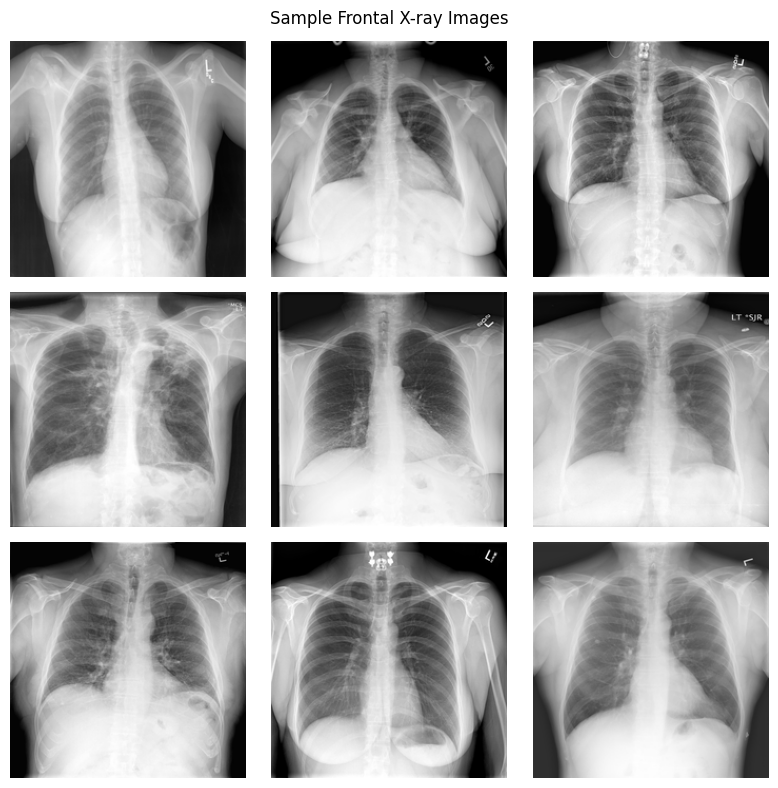

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("Sample Frontal X-ray Images")
plt.tight_layout()
plt.show()

The sample frontal X-ray images show consistent anatomical structures, including clear lung fields, rib boundaries, and heart silhouettes.

There is visible variability across samples, with some images showing potential abnormalities such as opacities or asymmetry, suggesting the dataset contains both normal and pathological cases.

The images are centered and aligned, indicating successful preprocessing and suitability for downstream modeling.

In [4]:
sizes = []

for i in range(len(data)):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data
    sizes.append(img.size)

set(sizes)

{(224, 224)}

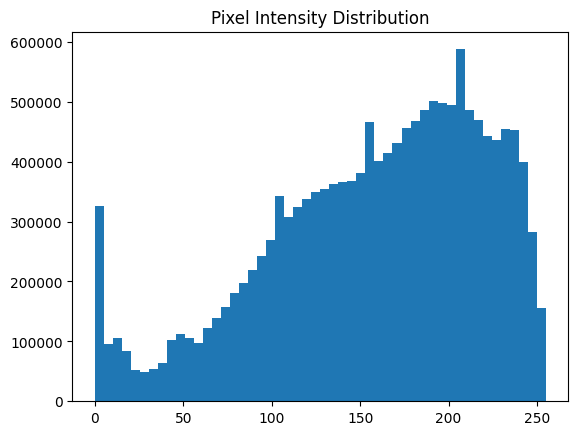

In [5]:
pixels = []

for i in range(100):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data

    img_arr = np.array(img)
    pixels.extend(img_arr.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

The pixel intensity distribution spans the full grayscale range (0–255), indicating that the images preserve sufficient contrast information.

The distribution is skewed toward higher intensity values, which is expected in chest X-rays due to large bright regions such as bones and background areas.

The absence of extreme spikes or degenerate distributions suggests that the images are not corrupted and have been properly normalized.

In [6]:
means = []
for i in range(100):
    img_data = data[i]["img_frontal_processed"]
    if isinstance(img_data, dict) and "bytes" in img_data:
        img = Image.open(io.BytesIO(img_data["bytes"]))
    else:
        img = img_data

    img_arr = np.array(img)
    means.append(img_arr.mean())

print(np.mean(means), np.std(means))

158.0097532684949 16.440003014495094


The average pixel intensity across sampled images is approximately 158 with a standard deviation of 16.4.

The relatively high mean intensity reflects the presence of bright regions such as bones and background in chest X-ray images.

The low standard deviation suggests that pixel intensity is consistent across samples, indicating stable preprocessing and uniform image quality.

This consistency is beneficial for model training, suggesting that the dataset is well-normalized, as it reduces variability unrelated to underlying pathology.

### Multi-View Comparison

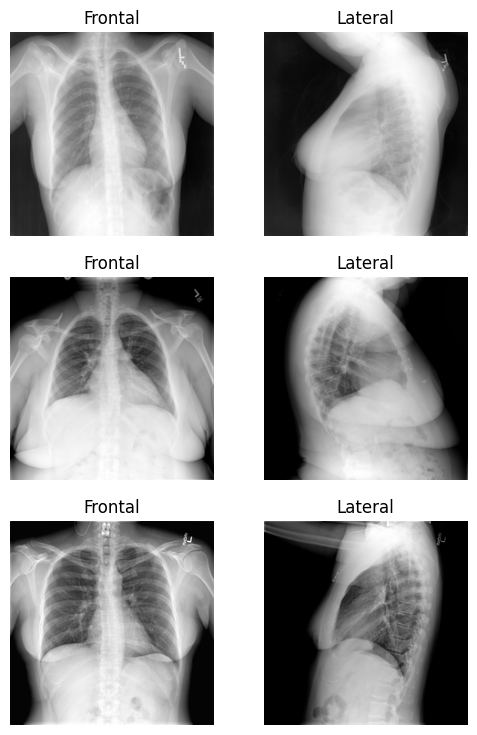

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i in range(3):
    # Frontal
    img_f = data[i]["img_frontal_processed"]
    if isinstance(img_f, dict) and "bytes" in img_f:
        img_f = Image.open(io.BytesIO(img_f["bytes"]))

    axes[i, 0].imshow(img_f, cmap="gray")
    axes[i, 0].set_title("Frontal")
    axes[i, 0].axis("off")

    # Lateral
    img_l = data[i]["img_lateral_processed"]
    if isinstance(img_l, dict) and "bytes" in img_l:
        img_l = Image.open(io.BytesIO(img_l["bytes"]))

    axes[i, 1].imshow(img_l, cmap="gray")
    axes[i, 1].set_title("Lateral")
    axes[i, 1].axis("off")

plt.show()

Each sample contains both frontal and lateral views, providing complementary perspectives of the chest.

While frontal images capture the overall lung structure, lateral views provide additional depth information that may help identify abnormalities not visible in a single view.

This multi-view setup suggests potential for multimodal or multi-input modeling approaches.

### Summary

Overall, the image data appears clean, standardized, and suitable for CNN-based modeling, with sufficient variability to capture clinically relevant patterns.

## Text EDA

In [8]:
# #Text Preprocess completed -> ds_cleaned
# from datasets import load_from_disk
# from google.colab import drive
# drive.mount('/content/drive')
# # ds_cleaned = load_from_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned.zip")
# # zip_file_path = "/content/drive/MyDrive/cs109b_project/ds_cleaned.zip"
# # extraction_path = "/content/drive/MyDrive/cs109b_project"
# # !unzip -q "{zip_file_path}" -d "{extraction_path}"


df = dataset.to_pandas()
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Total samples: 3388
Columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'img_frontal', 'img_lateral', 'img_frontal_processed', 'img_lateral_processed', 'is_valid', 'findings_refined', 'impression_refined', 'findings_wc', 'impression_wc', 'xxxx_findings', 'xxxx_impression']


### Text Overview

In [9]:
def word_count(text):
    if text is None or str(text).strip() == "":
        return 0
    return len(str(text).strip().split())

In [10]:

df["findings_wc"]   = df["findings_refined"].apply(word_count)
df["impression_wc"] = df["impression_refined"].apply(word_count)

print("=== Text Column Summary ===")
summary = pd.DataFrame({
    "column": ["findings_refined", "impression_refined"],
    "total": [len(df), len(df)],
    "non_empty": [(df["findings_wc"] > 0).sum(), (df["impression_wc"] > 0).sum()],
    "missing": [(df["findings_wc"] == 0).sum(), (df["impression_wc"] == 0).sum()],
    "mean_words":[df[df["findings_wc"] > 0]["findings_wc"].mean().round(1),
                  df[df["impression_wc"] > 0]["impression_wc"].mean().round(1)],
    "median_words": [df[df["findings_wc"]  > 0]["findings_wc"].median(),
                    df[df["impression_wc"] > 0]["impression_wc"].median()],
    "max_words": [df["findings_wc"].max(), df["impression_wc"].max()],
})

print(summary.to_string(index=False))

=== Text Column Summary ===
            column  total  non_empty  missing  mean_words  median_words  max_words
  findings_refined   3388       2943      445        31.0          29.0        149
impression_refined   3388       3370       18        10.1           5.0        133


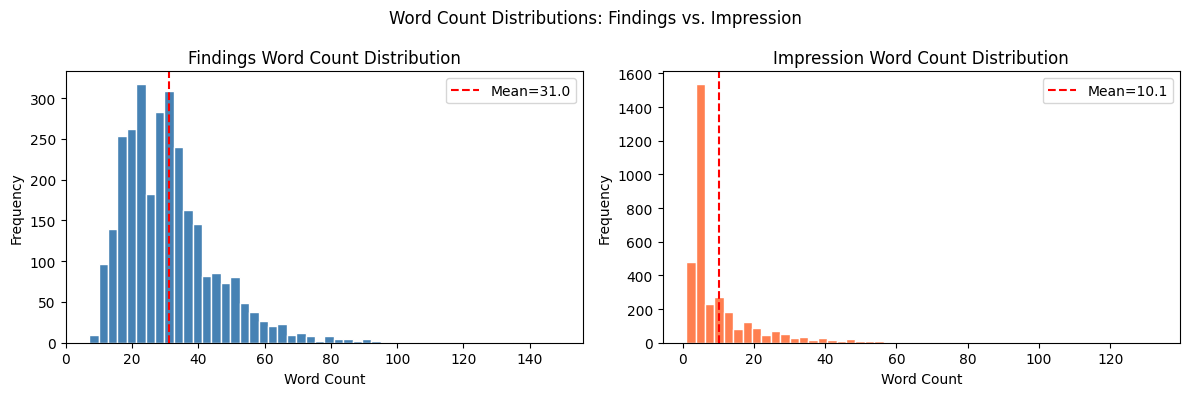

In [11]:
findings_mean = df[df["findings_wc"] > 0]["findings_wc"].mean()
impression_mean = df[df["impression_wc"] > 0]["impression_wc"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df["findings_wc"] > 0]["findings_wc"], bins=50,
             color="steelblue", edgecolor="white")
axes[0].set_title("Findings Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(findings_mean, color="red", linestyle="--", label=f"Mean={findings_mean:.1f}")
axes[0].legend()

axes[1].hist(df[df["impression_wc"] > 0]["impression_wc"], bins=50,
             color="coral", edgecolor="white")
axes[1].set_title("Impression Word Count Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(impression_mean, color="red", linestyle="--", label=f"Mean={impression_mean:.1f}")
axes[1].legend()

plt.suptitle("Word Count Distributions: Findings vs. Impression")
plt.tight_layout()
plt.show()

For the two description columns that could potentially be used as the generation ground-truth, 'findings' and 'impression', in the cleaned dataset, which has also been stripped of numbering, the summary and distributions above reveal some key insights. The findings word count distribution is approximately bell-shaped, centered around its mean of 31 words (among only non-empty samples) with a modest right tail extending to 100 words, indicating that findings are consistently verbose across samples. In contrast, the impression distribution is heavily right-skewed as the tallest bar sits near 0-5 words with frequency exceeding 1,500, dropping sharply afterward, confirming that the vast majority of impressions are very short single-sentence conclusions while a small subset of pathological cases produce notably longer multi-finding outputs that pull the mean up to 10.1.

More importantly, findings has 445 missing values (13%) compared to only 18 (0.5%) for impression. This missingness in findings is not addressed by the image-based filtering applied in preprocessing, where samples were only filtered on image validity, not text completeness.  As a result, using findings as a generation target would either discard 13% of the dataset or require imputation.

These observations jointly motivate using impression as the generation target for out redefined task as it is more complete, more concise and structured, and clinically more meaningful as the radiologist's final actionable conclusion.

In [12]:
missing_matrix = pd.DataFrame({
    "findings_missing": df["findings_wc"] == 0,
    "impression_missing": df["impression_wc"] == 0,
})

print(f"\nMissing findings but have impression: "
      f"{(missing_matrix['findings_missing'] & ~missing_matrix['impression_missing']).sum()}")
print(f"Missing both: "
      f"{(missing_matrix['findings_missing'] & missing_matrix['impression_missing']).sum()}")


Missing findings but have impression: 433
Missing both: 12


Of the 445 samples missing findings, 433 (97.3%) still have a valid impression, and only 12 samples are missing both. This confirms that impression is a far more reliable target column as it is present even when findings are absent, suggesting that radiologists prioritized writing the
clinical conclusion over the detailed observations in some cases. This further solidifies the choice of impression as the generation target.

In [13]:
numbered = df[df["impression"].str.contains(r'^\s*1[\.\)]', na=False, regex=True)]
print(f"Total numbered impressions: {len(numbered)}")
print(numbered[["impression", "impression_refined"]][2:3].to_string())

Total numbered impressions: 655
                                                                                                                                                                                                                                                                           impression                                                                                                                                                                                                                                                               impression_refined
27  1. Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, most consistent with atelectasis/infiltrate. 2. Stable enlarged cardiomediastinal silhouette. Stable pulmonary vascular congestion. .  Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, m

One limitation of the current text preprocessing is the inconsistent use of '[SEP]' tag across samples. Approximately 19% of impression originally contained numbered findings (e.g., "1. Cardiomegaly. 2. Pleural effusion."), corresponding to samples where radiologists originally enumerated multiple distinct findings, which were converted to '[SEP]'-delimited boundaries during preprocessing. The remaining impressions contain a single finding and therefore require no separator. This means '[SEP]' is semantically meaningful where present, but its absence simply indicates a single-finding impression. The primary open question for following training is whether to retain '[SEP]' as a special token or normalize to flat text, depending on the final model architecture chosen.

### XXXX Tokens

In [14]:
def count_xxxx(text):
    if text is None:
        return 0
    return len(re.findall(r'XXXX', str(text), re.IGNORECASE))

df["xxxx_findings"] = df["findings_refined"].apply(count_xxxx)
df["xxxx_impression"] = df["impression_refined"].apply(count_xxxx)

print("=== XXXX Token Summary ===")
print(f"Samples with XXXX in findings: {(df['xxxx_findings'] > 0).sum()} "
      f"({(df['xxxx_findings'] > 0).mean():.1%})")
print(f"Samples with XXXX in impression: {(df['xxxx_impression'] > 0).sum()} "
      f"({(df['xxxx_impression'] > 0).mean():.1%})")
print(f"\nMean XXXX per findings sample: {df[df['xxxx_findings']   > 0]['xxxx_findings'].mean():.2f}")
print(f"Mean XXXX per impression sample: {df[df['xxxx_impression'] > 0]['xxxx_impression'].mean():.2f}")

=== XXXX Token Summary ===
Samples with XXXX in findings: 1220 (36.0%)
Samples with XXXX in impression: 548 (16.2%)

Mean XXXX per findings sample: 1.65
Mean XXXX per impression sample: 1.76


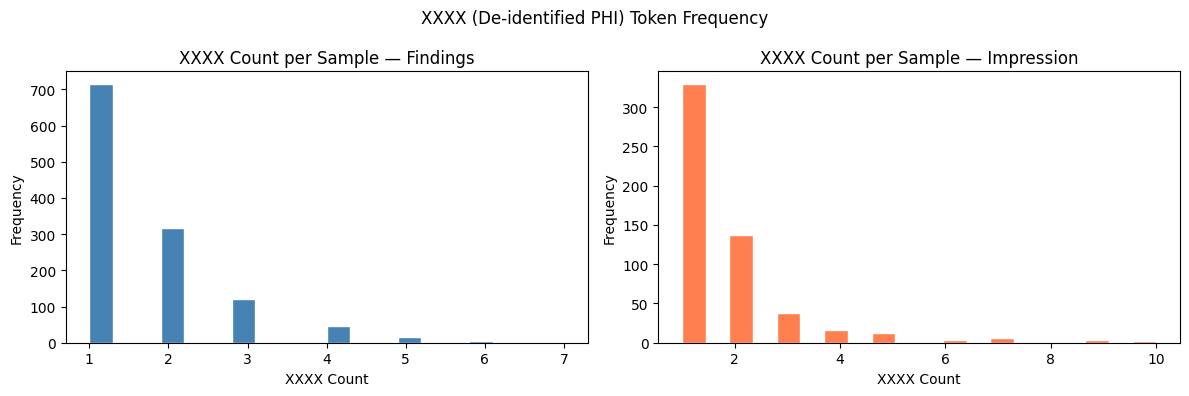

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df["xxxx_findings"] > 0]["xxxx_findings"], bins=20,
             color="steelblue", edgecolor="white")
axes[0].set_title("XXXX Count per Sample — Findings")
axes[0].set_xlabel("XXXX Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(df[df["xxxx_impression"] > 0]["xxxx_impression"], bins=20,
             color="coral", edgecolor="white")
axes[1].set_title("XXXX Count per Sample — Impression")
axes[1].set_xlabel("XXXX Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("XXXX (De-identified PHI) Token Frequency")
plt.tight_layout()
plt.show()

XXXX tokens serve as placeholders for de-identified protected health information (PHI), such as patient names, ages, and dates, appearing in 36% of findings samples and 16% of impression samples. The higher prevalance in findings is expected since findings are more verbose and more likely to reference patient-specific contextual information.

Both distributions are heavily concentrated at low counts (1-2 XXXX tokens per sample), with frequency dropping sharply beyond that. Findings extend up to 7 XXXX tokens while impressions reach up to 10, though these high counts are extremely rare.

For model training, XXXX tokens in the target (impression) can be problematic as the model would need to learn to generate XXXX as an output token, which is meaningless and potentially misleading. A practical decision would be to strip XXXX from impression targets entirely before training, or replace them with a generic placeholder the tokenizer natively supports.

In [16]:
def get_corpus(series):
    all_text = " ".join([str(x) for x in series.dropna() if word_count(x) > 0])
    # remove XXXX and SEP tokens for vocabulary analysis
    all_text = re.sub(r'XXXX', '', all_text, flags=re.IGNORECASE)
    all_text = re.sub(r'\[SEP\]', '', all_text)
    return all_text

def vocab_size(text):
    words = re.findall(r'\b[a-z]{2,}\b', text.lower())
    return len(set(words)), len(words)

# def top_words(text, n=20):
#     words = re.findall(r'\b[a-z]{3,}\b', text.lower())
#     words = [w for w in words if w not in STOPWORDS]
#     return Counter(words).most_common(n)

In [17]:
findings_text = get_corpus(df["findings_refined"])
impression_text = get_corpus(df["impression_refined"])

findings_unique, findings_total = vocab_size(findings_text)
impression_unique, impression_total = vocab_size(impression_text)

print("=== Vocabulary Summary ===")
print(f"Findings — unique tokens: {findings_unique:,}, total tokens: {findings_total:,}")
print(f"Impression — unique tokens: {impression_unique:,}, total tokens: {impression_total:,}")

=== Vocabulary Summary ===
Findings — unique tokens: 1,475, total tokens: 88,661
Impression — unique tokens: 1,384, total tokens: 32,632


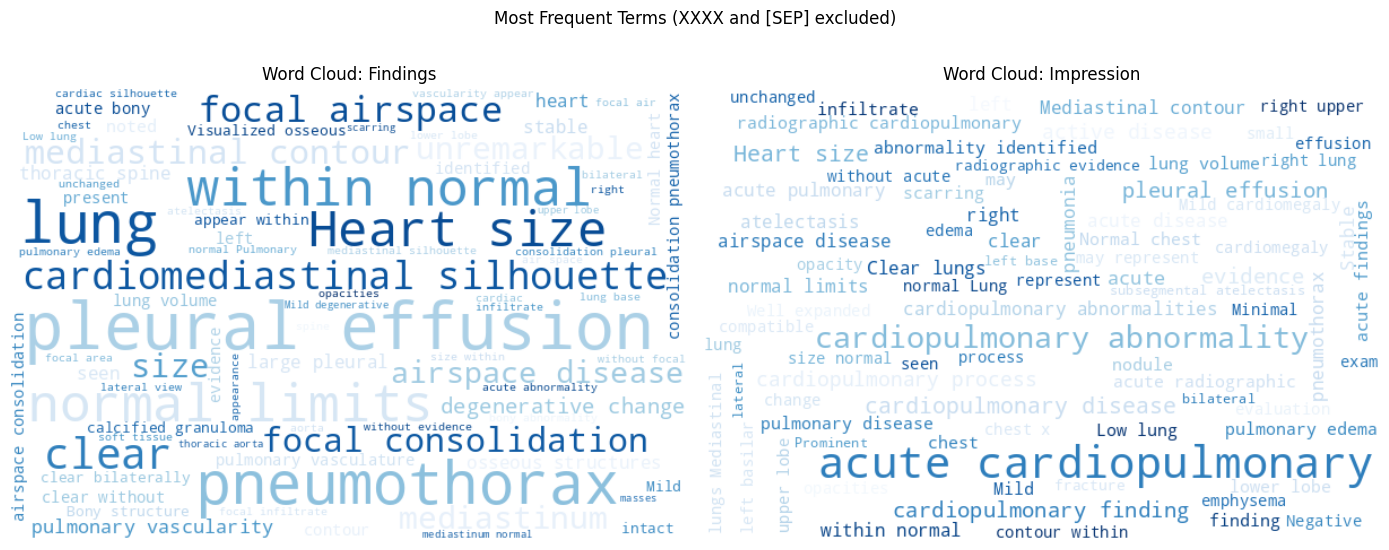

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, text, title in zip(axes,
                            [findings_text, impression_text],
                            ["Findings", "Impression"]):
    wc = WordCloud(width=600, height=400,
                   background_color="white",
                   colormap="Blues",
                   max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud: {title}")

plt.suptitle("Most Frequent Terms (XXXX and [SEP] excluded)")
plt.tight_layout()
plt.show()

The vocabulary analysis reveals clear differences in language style between the two text columns. Findings uses 1,475 unique tokens across 88,661 total tokens, while impression uses 1,384 unique tokens across only 32,632 total tokens. Despite having a similar vocabulary size, impression uses far fewer total words， confirming its concise, formulaic nature.

The word clouds further illustrate this contrast. Findings vocabulary is dominated by specific anatomical descriptors and observations: "pleural effusion", "pneumothorax", "focal consolidation", "cardiomediastinal silhouette", and "osseous structures" — detailed radiological observations
that describe what is seen in the image. In contrast, impression vocabulary centers around conclusive clinical language: "acute cardiopulmonary", "cardiopulmonary abnormality", "clear lungs", "heart size", and "pleural effusion", which are shorter, more standardized phrases that summarize the bottom-line clinical conclusion.

This distinction is important for model training. The impression vocabulary is smaller and more formulaic, meaning the generation model needs to learn a more constrained output space compared to findings. The high frequency of phrases like "no acute cardiopulmonary process" and "clear lungs" in the impression cloud also visually confirms the class imbalance noted earlier: a large proportion of impressions describe normal or unremarkable findings, which the model will need to handle carefully to avoid defaulting to generic normal outputs for all inputs.

## Extended EDA: Pretrained Medical LLM Review of Image–Text Pairs

As an extended EDA step, we may sample a small subset of frontal and lateral chest X-ray studies and compare the outputs of a general-purpose or medical vision-language model with the dataset’s `impression_refined` field, which is the cleaned and standardized target text selected for our project. The purpose of this comparison is not to generate new labels, but to assess whether the image patterns recognized by the vision-language model are broadly consistent with the short clinical summaries already present in the dataset. Because `impression_refined` is shorter, cleaner, and more complete than `findings`, it provides the most appropriate reference for this qualitative sanity check.

Since we do not have access to a radiologist, this step will be used only as supplementary evidence for image-text consistency and task validity, not as formal supervision, feature engineering, or final model evaluation.

As a supplementary extended EDA step, we plan to use **CheXagent** (https://github.com/Stanford-AIMI/CheXagent?tab=readme-ov-file), a pretrained chest X-ray vision-language model from Stanford AIMI, to qualitatively inspect a small sample of our cleaned frontal and lateral studies.

The CheXagent repository describes it as a foundation model for chest X-ray interpretation and provides built-in functions for tasks such as disease identification, findings generation, image-text matching, and findings summarization, which makes it a good fit for our exploratory image–text consistency check. In our project, we will not use CheXagent as a source of new labels or formal supervision. Instead, we will compare its qualitative outputs with our dataset’s impression_refined field on a small sample to see whether the model identifies broadly consistent radiographic patterns, providing a sanity check on the validity of the image–text pairs and the feasibility of our revised image-to-impression task. CheXagent is provided for research purposes only, so this step will remain purely exploratory.

In [19]:
# !pip uninstall -y transformers
# !pip install -q transformers==4.39.0 accelerate opencv-python albumentations sentencepiece protobuf

In [20]:
import os
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "StanfordAIMI/CheXagent-2-3b-srrg-impression"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32


# 2. Load model

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    trust_remote_code=True
)
model = model.to(dtype)
model.eval()


# 3. Make temp folder for images

os.makedirs("chexagent_temp", exist_ok=True)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:622: UserWarning: for logit_scale: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

### 1. Run and test One sample

This step tests the pretrained medical vision-language model on a single chest X-ray study before scaling to multiple samples. By comparing the generated output with the dataset’s impression_refined label, we can first check whether the model produces a clinically reasonable and broadly aligned summary. This serves as an initial sanity check for image–text consistency in our cleaned dataset.


In [21]:

# 4. Function: run one sample
import io
from PIL import Image
import pandas as pd

def run_chexagent_on_sample(dataset, idx, prompt="Structured Radiology Report Generation for Impression Section",
                            ref = "impression_refined"):
    # Support both pandas DataFrame and HuggingFace dataset indexing
    sample = dataset.iloc[idx] if isinstance(dataset, pd.DataFrame) else dataset[idx]

    frontal_img = sample["img_frontal_processed"]
    if isinstance(frontal_img, dict) and "bytes" in frontal_img:
        frontal_img = Image.open(io.BytesIO(frontal_img["bytes"]))

    lateral_img = sample["img_lateral_processed"]
    if isinstance(lateral_img, dict) and "bytes" in lateral_img:
        lateral_img = Image.open(io.BytesIO(lateral_img["bytes"]))

    frontal_path = f"chexagent_temp/sample_{idx}_frontal.png"
    lateral_path = f"chexagent_temp/sample_{idx}_lateral.png"

    frontal_img.save(frontal_path)
    lateral_img.save(lateral_path)

    paths = [frontal_path, lateral_path]

    query = tokenizer.from_list_format(
        [*[{"image": path} for path in paths], {"text": prompt}]
    )

    conv = [
        {"from": "system", "value": "You are a helpful assistant."},
        {"from": "human", "value": query}
    ]

    model_inputs = tokenizer.apply_chat_template(
        conv,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    output = model.generate(
        **model_inputs,
        do_sample=False,
        num_beams=1,
        max_new_tokens=64,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=True
    )[0]

    input_len = model_inputs["input_ids"].shape[1]
    response = tokenizer.decode(
        output[input_len:],
        skip_special_tokens=True
    ).strip()

    return {
        "uid": sample["uid"],
        "generated_impression": response,
        "reference_impression": sample[ref]
    }


# 5. Test one sample

result = run_chexagent_on_sample(dataset, 1, prompt = "Generate a one- to two-sentence radiology impression for this chest X-ray study. Be concise and do not produce findings or explanation.")

print("UID:", result["uid"])
print("\nCheXagent output:")
print(result["generated_impression"])
print("\nReference impression_refined:")
print(result["reference_impression"])

This is a friendly reminder - the current text generation call will exceed the model's predefined maximum length (2048). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


UID: 2

CheXagent output:
1. No evidence of acute cardiopulmonary disease.
2. No evidence of pneumonia.

Reference impression_refined:
No acute pulmonary findings.


In this example, CheXagent generated a more detailed impression than the dataset reference, but both outputs were clinically consistent in indicating no acute cardiopulmonary abnormality. The main difference is that the model explicitly listed several negative findings and mentioned stable post-surgical changes, while the reference impression remained shorter and more concise.

### 2. Run and test  10 samples
This step extends the initial single-sample check by running CheXagent on 10 sampled studies and comparing the generated summaries with the dataset’s `impression_refined` labels. To make the comparison more systematic, we also visualize BLEU, ROUGE-1, and ROUGE-L scores across samples as supporting metrics.

In [22]:
# !pip install -q rouge_score
import random
import re
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# 1. normalize text
def normalize_for_eval(text):
    if text is None:
        return ""
    text = str(text).lower()
    text = re.sub(r'xxxx', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\[sep\]', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 2. compute metrics
def compute_text_metrics(generated_text, reference_text):
    gen = normalize_for_eval(generated_text)
    ref = normalize_for_eval(reference_text)

    smoothie = SmoothingFunction().method1
    bleu = sentence_bleu(
        [ref.split()],
        gen.split(),
        smoothing_function=smoothie
    )

    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
    rouge_scores = scorer.score(ref, gen)

    return {
        "bleu": bleu,
        "rouge1_f1": rouge_scores["rouge1"].fmeasure,
        "rougeL_f1": rouge_scores["rougeL"].fmeasure,
        "gen_len": len(gen.split()),
        "ref_len": len(ref.split())
    }

# 3. unified evaluator
def evaluate_on_df(df, generate_fn, model_name="model"):
    results = []

    for idx, row in df.iterrows():
        uid = row["uid"]
        ref = row["reference_text"]

        try:
            gen = generate_fn(row)
            metrics = compute_text_metrics(gen, ref)

            results.append({
                "idx": idx,
                "uid": uid,
                "model": model_name,
                "generated_impression": gen,
                "reference_impression": ref,
                **metrics
            })

        except Exception as e:
            results.append({
                "idx": idx,
                "uid": uid,
                "model": model_name,
                "generated_impression": f"ERROR: {e}",
                "reference_impression": ref,
                "bleu": None,
                "rouge1_f1": None,
                "rougeL_f1": None,
                "gen_len": None,
                "ref_len": None
            })

    return pd.DataFrame(results)

# 4. build smoke_df
n_samples = 10
ref_text = "impression_refined"
smoke_df = df.sample(n=n_samples, random_state=109).copy().reset_index(drop=True)
smoke_df["reference_text"] = smoke_df[ref_text]
prompt = "Generate a one- to two-sentence radiology impression for this chest X-ray study. Be concise and do not produce findings or explanation."

# 5. wrap Stanford model
def stanford_generate_fn(row):
    idx = row.name
    out = run_chexagent_on_sample(smoke_df, idx, prompt = prompt)
    return out["generated_impression"]

# 6. run smoke test
compare_df = evaluate_on_df(
    smoke_df,
    generate_fn=stanford_generate_fn,
    model_name="stanford_model"
)

compare_df


,idx,uid,model,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,gen_len,ref_len
0,0,441,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormality.,0.017730,0.206897,0.206897,25,4
1,1,1294,stanford_model,1. No evidence of pneumothorax.\n2. No acute c...,No active disease.,0.018850,0.285714,0.285714,11,3
2,2,2070,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Subtle interstitial markings bilateral, may re...",0.006980,0.050000,0.050000,27,13
3,3,2236,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Unremarkable chest x-XXXX.,0.000000,0.000000,0.000000,17,3
4,4,3925,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute pulmonary disease.,0.015139,0.285714,0.285714,17,4
5,5,1730,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormalities.,0.015146,0.181818,0.181818,29,4
6,6,3287,stanford_model,"1. Left lower lobe consolidation, suggestive o...",Right midlung and left basilar airspace densit...,0.007088,0.140351,0.070175,37,21
7,7,1414,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Heart size normal. Lungs clear. Resolution of ...,0.012301,0.142857,0.142857,16,12
8,8,3767,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Heart size, mediastinal silhouette, pulmonary ...",0.013636,0.324324,0.216216,17,20
9,9,1094,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No focal lung consolidation.,0.009849,0.148148,0.148148,23,4


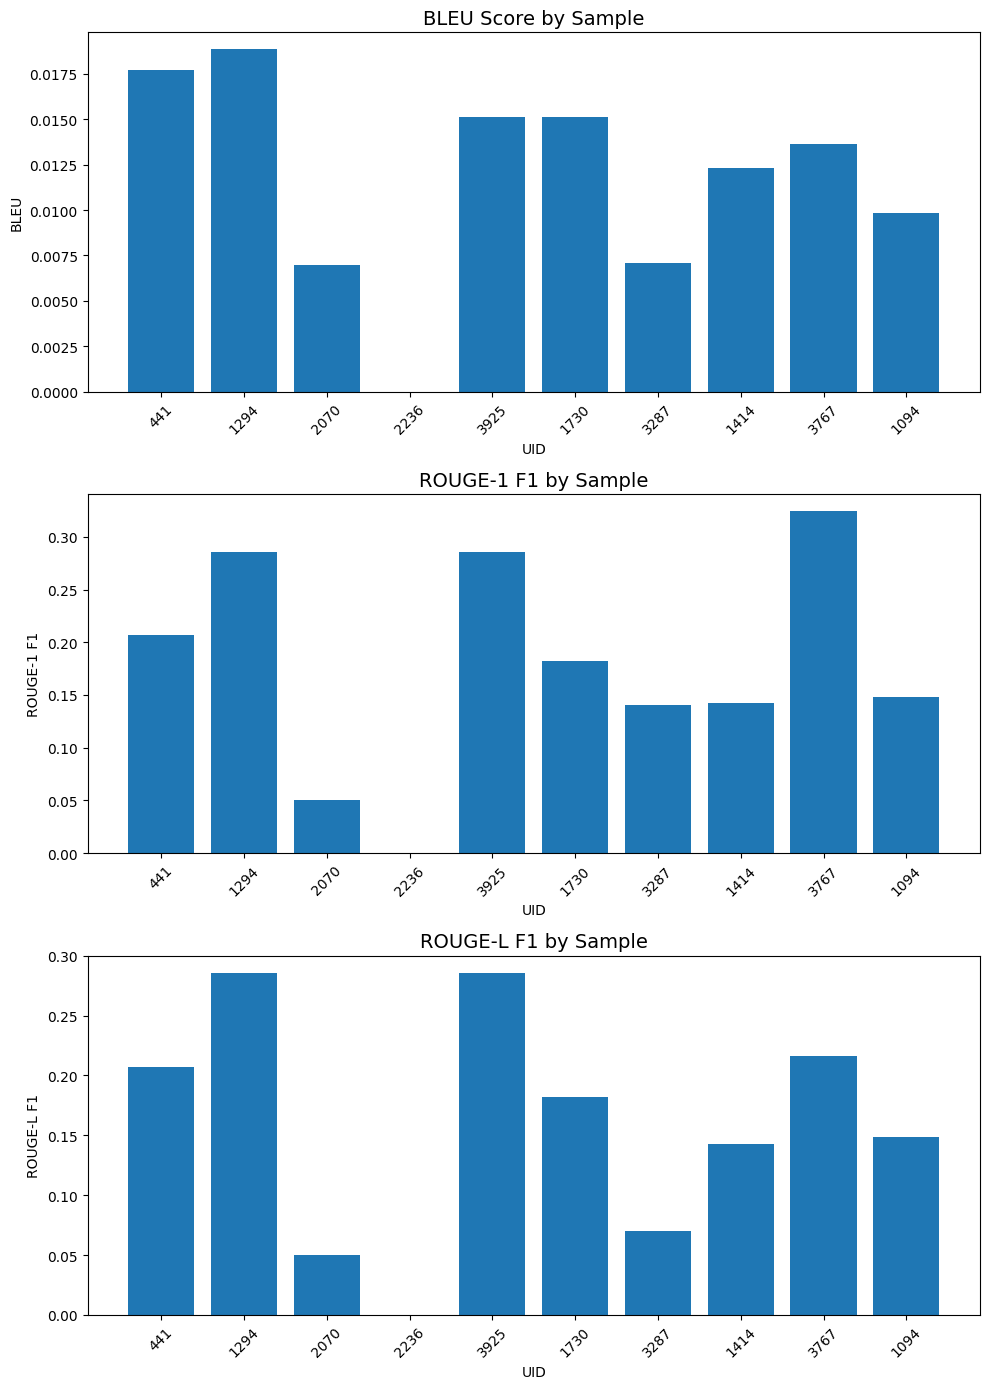

In [23]:
plot_df = compare_df.dropna(subset=["bleu", "rouge1_f1", "rougeL_f1"]).copy()

fig, axes = plt.subplots(3, 1, figsize=(10, 14))

axes[0].bar(plot_df["uid"].astype(str), plot_df["bleu"])
axes[0].set_title("BLEU Score by Sample", fontsize=14)
axes[0].set_xlabel("UID")
axes[0].set_ylabel("BLEU")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(plot_df["uid"].astype(str), plot_df["rouge1_f1"])
axes[1].set_title("ROUGE-1 F1 by Sample", fontsize=14)
axes[1].set_xlabel("UID")
axes[1].set_ylabel("ROUGE-1 F1")
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(plot_df["uid"].astype(str), plot_df["rougeL_f1"])
axes[2].set_title("ROUGE-L F1 by Sample", fontsize=14)
axes[2].set_xlabel("UID")
axes[2].set_ylabel("ROUGE-L F1")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Across the 10 sampled studies, CheXagent outputs were generally broadly clinically consistent with `impression_refined`, but they were often more detailed than the reference labels. This led to relatively low BLEU scores but moderately higher ROUGE-1 and ROUGE-L scores, suggesting limited exact wording overlap but partial content overlap.

In many cases, both the model and the dataset label agreed on the main conclusion, such as the absence of acute cardiopulmonary abnormality, even when the model listed additional negative findings or chronic details not included in the reference.

One notable exception was the sample with all-zero BLEU and ROUGE scores, which indicates no lexical overlap at all; however, this likely reflects a strong wording mismatch, extra detail, and label artifacts such as `XXXX`, rather than automatically implying clinical disagreement. Overall, these results support that `impression_refined` is a meaningful and usable target label for the revised task, while also showing that automatic overlap metrics should be interpreted cautiously because semantic agreement can still exist even when lexical similarity is very low. They also suggest that artifacts such as `XXXX` should be explicitly handled in the feature engineering stage, since they can distort text overlap metrics and introduce noise into the target representation without adding meaningful clinical information.

# 2. Feature engineering

We have already completed the main preprocessing and EDA steps needed to clean and understand both the image and text portions of the dataset. In particular, we identified `impression_refined` as the most appropriate target text because it is shorter, cleaner, and more complete than findings, while also finding that special artifacts such as `XXXX` and `[SEP]` remain in a subset of samples. The next feature-engineering step is therefore to refine this target text further by deciding how to handle these artifacts so that the model learns clinically meaningful language rather than formatting or de-identification noise.

### 1. Removing xxxx

As the first feature-engineering step, we further refine the target text by removing `XXXX` tokens from `impression_refined`. As in previous part we found These tokens are de-identification placeholders rather than meaningful clinical content, so keeping them would add noise to the target text and could distort both training and evaluation. We therefore create a new column, `impression_final`, where `XXXX` is removed and spacing is cleaned again.

In [24]:
def remove_xxxx(text):
    if text is None:
        return None
    text = str(text)
    text = re.sub(r'XXXX', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

ds_cleaned = dataset.map(
    lambda x: {"impression_final": remove_xxxx(x["impression_refined"])}
)

In [25]:
check_df = ds_cleaned.select(range(10)).to_pandas()[
    ["uid", "impression_refined", "impression_final"]
]
check_df

,uid,impression_refined,impression_final
0,1,Normal chest x-XXXX.,Normal chest x-.
1,2,No acute pulmonary findings.,No acute pulmonary findings.
2,3,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p..."
3,4,Bullous emphysema and interstitial fibrosis. [...,Bullous emphysema and interstitial fibrosis. [...
4,5,No acute cardiopulmonary abnormality.,No acute cardiopulmonary abnormality.
5,6,No acute cardiopulmonary findings.,No acute cardiopulmonary findings.
6,7,Basilar atelectasis. No confluent lobar consol...,Basilar atelectasis. No confluent lobar consol...
7,8,No acute cardiopulmonary disease.,No acute cardiopulmonary disease.
8,9,Increased size of density in the left cardioph...,Increased size of density in the left cardioph...
9,10,No acute cardiopulmonary process.,No acute cardiopulmonary process.


We removed `XXXX` tokens from the target text!

### 2. Handling [SEP]
After removing `XXXX`, the next feature-engineering step is to handle `[SEP]` in the target text. In our cleaned dataset, `[SEP]` was introduced during preprocessing to preserve the structure of numbered multi-finding impressions. For the first baseline, we convert `[SEP]` into normal punctuation so that the target text remains clinically meaningful while becoming more natural for sequence generation.

In [26]:

def normalize_sep(text, sep_replacement=". "):
    if text is None:
        return None
    text = str(text)
    text = re.sub(r'\[SEP\]', sep_replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\s*\.\s*\.', '.', text)   # clean double periods
    text = re.sub(r'\s+,', ',', text)         # clean spacing before commas
    return text


ds_cleaned = ds_cleaned.map(
    lambda x: {"impression_final": normalize_sep(x["impression_final"])}
)

In [27]:
check_df = ds_cleaned.select(range(10)).to_pandas()[
    ["uid", "impression_refined", "impression_final"]
]
check_df

,uid,impression_refined,impression_final
0,1,Normal chest x-XXXX.,Normal chest x-.
1,2,No acute pulmonary findings.,No acute pulmonary findings.
2,3,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p..."
3,4,Bullous emphysema and interstitial fibrosis. [...,Bullous emphysema and interstitial fibrosis. P...
4,5,No acute cardiopulmonary abnormality.,No acute cardiopulmonary abnormality.
5,6,No acute cardiopulmonary findings.,No acute cardiopulmonary findings.
6,7,Basilar atelectasis. No confluent lobar consol...,Basilar atelectasis. No confluent lobar consol...
7,8,No acute cardiopulmonary disease.,No acute cardiopulmonary disease.
8,9,Increased size of density in the left cardioph...,Increased size of density in the left cardioph...
9,10,No acute cardiopulmonary process.,No acute cardiopulmonary process.


This step replaces `[SEP]` with normal punctuation, such as periods or semicolons, making the target text more natural and easier for the model to learn while preserving the original multi-finding content.

In [28]:

from google.colab import drive
drive.mount('/content/drive')
ds_cleaned.save_to_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned_final")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving the dataset (0/5 shards):   0%|          | 0/3388 [00:00<?, ? examples/s]

Our EDA and feature engineering were guided by the revised goal of generating a short, clinically plausible `impression` summary from chest X-ray images and comparing frontal-only versus **frontal + lateral input. EDA showed that the cleaned images are standardized and suitable for modeling, while `impression` is shorter, cleaner, and more complete than `findings`, making it the better target text. Based on these results, we kept the processed image fields, created a cleaner target text by removing `XXXX` and normalizing `[SEP]`, and used a pretrained medical vision-language model as a supplementary sanity check to verify that the image patterns were broadly consistent with the dataset labels. Together, these steps make the original broad report-generation task more feasible and better aligned with the structure of the cleaned dataset.

# 3. Baseline Model

In [29]:
ds_cleaned_final = load_from_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned_final")
df = ds_cleaned_final.to_pandas()

While BLEU and ROUGE have been widely adopted as automatic evaluation metrics for natural language generation tasks, they rely on surface-level n-gram overlap between the generated text and reference text, making them sensitive to exact word matches and largely insensitive to semantic equivalence. In the context of radiology report generation, this is a notable limitation: clinically synonymous expressions such as "No acute cardiopulmonary abnormalities detected." and "No acute cardiopulmonary findings." convey identical diagnostic meaning yet would receive low overlap scores under these metrics. As a result, BLEU and ROUGE may underestimate the quality of generated impressions that are semantically accurate but lexically diverse.

To address this limitation, we additionally adopt BERTScore as a complementary evaluation metric. BERTScore leverages contextual embeddings from a pre-trained BERT model to compute token-level similarity between the generated and reference texts. Specifically, it matches each token in the candidate sentence to the most similar token in the reference sentence using cosine similarity in the embedding space, and aggregates these scores into precision, recall, and F1 values. By operating in a dense semantic space rather than relying on discrete token overlap, BERTScore is better equipped to capture meaning-preserving paraphrases and domain-specific linguistic variation, making it a more clinically sensitive measure for evaluating generated radiology impressions.

In [30]:
#! pip install bert-score

In [35]:
from bert_score import score
import warnings
warnings.filterwarnings('ignore')
from transformers import logging
logging.set_verbosity_error()
def compute_text_metrics(generated_text, reference_text):
    gen = normalize_for_eval(generated_text)
    ref = normalize_for_eval(reference_text)

    smoothie = SmoothingFunction().method1
    bleu = sentence_bleu(
        [ref.split()],
        gen.split(),
        smoothing_function=smoothie
    )

    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
    rouge_scores = scorer.score(ref, gen)

    # Calculate BERTScore
    P, R, F1 = score([gen], [ref], lang="en", verbose=False)

    return {
        "bleu": bleu,
        "rouge1_f1": rouge_scores["rouge1"].fmeasure,
        "rougeL_f1": rouge_scores["rougeL"].fmeasure,
        "bertscore_p": P.item(),
        "bertscore_r": R.item(),
        "bertscore_f1": F1.item(),
        "gen_len": len(gen.split()),
        "ref_len": len(ref.split())
    }

n_samples = 10
ref_text = "impression_final"
smoke_df = df.sample(n=n_samples, random_state=109).copy().reset_index(drop=True)
smoke_df["reference_text"] = smoke_df[ref_text]

def stanford_generate_fn(row):
    idx = row.name
    out = run_chexagent_on_sample(smoke_df, idx, prompt = prompt, ref = ref_text)
    return out["generated_impression"]

compare_df = evaluate_on_df(
    smoke_df,
    generate_fn=stanford_generate_fn,
    model_name="stanford_model"
)

compare_df

,idx,uid,model,generated_impression,reference_impression,bleu,rouge1_f1,rougeL_f1,bertscore_p,bertscore_r,bertscore_f1,gen_len,ref_len
0,0,441,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormality.,0.017730,0.206897,0.206897,0.838375,0.928064,0.880942,25,4
1,1,1294,stanford_model,1. No evidence of pneumothorax.\n2. No acute c...,No active disease.,0.018850,0.285714,0.285714,0.831465,0.897285,0.863122,11,3
2,2,2070,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Subtle interstitial markings bilateral, may re...",0.006980,0.050000,0.050000,0.830411,0.849977,0.840080,27,13
3,3,2236,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Unremarkable chest x-.,0.000000,0.000000,0.000000,0.814566,0.796904,0.805638,17,3
4,4,3925,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute pulmonary disease.,0.015139,0.285714,0.285714,0.845081,0.914090,0.878232,17,4
5,5,1730,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No acute cardiopulmonary abnormalities.,0.015146,0.181818,0.181818,0.845685,0.935574,0.888362,29,4
6,6,3287,stanford_model,"1. Left lower lobe consolidation, suggestive o...",Right midlung and left basilar airspace densit...,0.007088,0.140351,0.070175,0.820733,0.835123,0.827865,37,21
7,7,1414,stanford_model,1. No evidence of acute cardiopulmonary diseas...,Heart size normal. Lungs clear. Resolution of ...,0.012301,0.142857,0.142857,0.850276,0.870809,0.860420,16,12
8,8,3767,stanford_model,1. No evidence of acute cardiopulmonary diseas...,"Heart size, mediastinal silhouette, pulmonary ...",0.013636,0.324324,0.216216,0.898777,0.866557,0.882372,17,20
9,9,1094,stanford_model,1. No evidence of acute cardiopulmonary diseas...,No focal lung consolidation.,0.009849,0.148148,0.148148,0.834792,0.899015,0.865714,23,4
